# Depth-edge analysis
Post-analysis for raw outputs from the YOLO + FoundationStereo pipeline.

Inputs expected in the selected run's `raw/` folder:
- depth.npy (float32 meters) or depth.exr (value in RED channel)
- edges.npy (uint8) or edges.png (uint8)

This notebook breaks the workflow into clear steps and displays results inline. It does not write any files to disk.

In [20]:
# Imports
import os, json
import numpy as np
import cv2
import imageio
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10,6)

In [21]:
# Parameters
# Set raw_dir to the path of a run's raw/ folder. Use a raw string on Windows, e.g., r'C\\path\\to\\run\\raw'
# If left as None, the next cell will try to auto-detect a suitable raw/ folder.
raw_dir = None  # e.g., r'C:\\Users\\1213123\\Documents\\Scripts\\FoundationStereo\\scripts\\unity_yolo\\output_3d_blocks\\your_run\\raw'

buffer_px = 4
roi_margin_px = 8
method = 'canny'  # 'sobel' | 'laplacian' | 'canny'
edge_thresh = None  # absolute threshold for sobel/laplacian (meters/pixel); if None uses percentile
edge_sigma = 0.33  # for automatic thresholding if edge_thresh is None
flatten_far_m = 5.0  # if depth > T meters, set to T to reduce sky/background artifacts
max_edge_dist_px = 2.5  # maximum allowed distance from loaded edge to keep a depth edge
# Smoothing (pre-filter) to reduce noise before edge detection
# If True, a Gaussian blur will be applied (applies to depth for sobel/laplacian,
# and to the normalized image for Canny). Ensure ksize is odd and >=1.
smooth = True
smooth_ksize = 5  # must be odd (1,3,5,...); use 1 to disable smoothing effectually
smooth_sigma = 1.0  # sigma for Gaussian; 0 means let OpenCV compute from ksize

# Roots to search for runs if raw_dir is None or invalid (relative to this notebook location)
search_roots = [
    r'./output_3d_blocks',
    r'../output_3d_blocks',
    r'../../scripts/unity_yolo/output_3d_blocks',
    r'./scripts/unity_yolo/output_3d_blocks',
    r'../run_files/output_3d_blocks',
]

print('Initial raw_dir:', raw_dir)
print('buffer_px =', buffer_px)
print('roi_margin_px =', roi_margin_px)
print('method =', method)
print('edge_thresh =', edge_thresh, 'edge_sigma =', edge_sigma)
print('flatten_far_m =', flatten_far_m)
print('max_edge_dist_px =', max_edge_dist_px)
print('smooth =', smooth, 'smooth_ksize =', smooth_ksize, 'smooth_sigma =', smooth_sigma)

Initial raw_dir: None
buffer_px = 4
roi_margin_px = 8
method = canny
edge_thresh = None edge_sigma = 0.33
flatten_far_m = 5.0
max_edge_dist_px = 2.5
smooth = True smooth_ksize = 5 smooth_sigma = 1.0


In [22]:
# Auto-detect and validate raw_dir
import time

def has_required_files(run_dir: str) -> bool:
    d_npy = os.path.join(run_dir, 'depth.npy')
    d_exr = os.path.join(run_dir, 'depth.exr')
    e_npy = os.path.join(run_dir, 'edges.npy')
    e_png = os.path.join(run_dir, 'edges.png')
    return (os.path.isfile(d_npy) or os.path.isfile(d_exr)) and (os.path.isfile(e_npy) or os.path.isfile(e_png))

if raw_dir is None or not os.path.isdir(raw_dir) or not has_required_files(raw_dir):
    print('\nTrying to auto-detect a raw/ folder...')
    candidates = []
    for root in search_roots:
        root_abs = os.path.abspath(root)
        if not os.path.isdir(root_abs):
            continue
        for dirpath, dirnames, filenames in os.walk(root_abs):
            if os.path.basename(dirpath).lower() == 'raw' and has_required_files(dirpath):
                # Score by most recent mtime among contained files
                try:
                    mtimes = [os.path.getmtime(os.path.join(dirpath, f)) for f in filenames]
                    score = max(mtimes) if mtimes else 0
                except Exception:
                    score = 0
                candidates.append((score, dirpath))
    if candidates:
        candidates.sort(reverse=True)
        print('Found candidates:')
        for i, (score, path) in enumerate(candidates[:10], 1):
            ts = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(score))
            print(f'  {i}. {path}  (latest file: {ts})')
        raw_dir = candidates[0][1]
        print('\nSelected raw_dir =', raw_dir)
    else:
        raise FileNotFoundError('Could not auto-detect a valid raw/ folder. Please set raw_dir to a specific path.')
else:
    print('Using provided raw_dir =', raw_dir)

# Quick peek at files inside raw_dir
try:
    names = os.listdir(raw_dir)
    print('\nraw_dir contents (first 20):')
    for n in names[:20]:
        print(' -', n)
except Exception as e:
    print('Warning: could not list raw_dir:', e)


Trying to auto-detect a raw/ folder...
Found candidates:
  1. c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files\output_3d_blocks\raw  (latest file: 2025-10-27 23:10:08)

Selected raw_dir = c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files\output_3d_blocks\raw

raw_dir contents (first 20):
 - depth.exr
 - depth.npy
 - depth_mm.png
 - disparity.exr
 - disparity.npy
 - disparity_u16.png
 - edges.npy
 - edges.png
 - meta.json


In [23]:
# Helpers (ported from analyze_depth_edges.py)
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def load_raw(raw_dir: str):
    depth_npy = os.path.join(raw_dir, 'depth.npy')
    edges_npy = os.path.join(raw_dir, 'edges.npy')
    depth_exr = os.path.join(raw_dir, 'depth.exr')
    edges_png = os.path.join(raw_dir, 'edges.png')

    if os.path.exists(depth_npy):
        depth = np.load(depth_npy).astype(np.float32)
    elif os.path.exists(depth_exr):
        d = imageio.imread(depth_exr)
        # If 3-channel EXR with value in red channel
        if d.ndim == 3 and d.shape[2] >= 1:
            depth = d[...,0].astype(np.float32)
        else:
            depth = d.astype(np.float32)
    else:
        raise FileNotFoundError('Could not find depth.npy or depth.exr in raw_dir')

    if os.path.exists(edges_npy):
        edges = np.load(edges_npy)
        if edges.dtype != np.uint8:
            edges = edges.astype(np.uint8)
        edges_bin = (edges > 0).astype(np.uint8)
    elif os.path.exists(edges_png):
        e = cv2.imread(edges_png, cv2.IMREAD_GRAYSCALE)
        edges_bin = (e > 0).astype(np.uint8)
    else:
        raise FileNotFoundError('Could not find edges.npy or edges.png in raw_dir')
    return depth, edges_bin

def buffer_edges(edges_bin: np.ndarray, buffer_px: int) -> np.ndarray:
    if buffer_px <= 0:
        return edges_bin.copy()
    k = 2 * buffer_px + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    return cv2.dilate(edges_bin, kernel, iterations=1)

def compute_roi_from_mask(mask: np.ndarray, margin: int = 0):
    ys, xs = np.where(mask > 0)
    if ys.size == 0 or xs.size == 0:
        return None
    y1, y2 = int(ys.min()), int(ys.max())
    x1, x2 = int(xs.min()), int(xs.max())
    if margin > 0:
        y1 -= margin; y2 += margin; x1 -= margin; x2 += margin
    h, w = mask.shape[:2]
    y1 = max(0, y1); x1 = max(0, x1)
    y2 = min(h - 1, y2); x2 = min(w - 1, x2)
    return x1, y1, x2, y2

def visualize_depth(depth: np.ndarray) -> np.ndarray:
    d = depth.copy()
    valid = np.isfinite(d) & (d > 0)
    if not valid.any():
        return np.zeros((*d.shape, 3), dtype=np.uint8)
    dmin = float(np.percentile(d[valid], 5))
    dmax = float(np.percentile(d[valid], 95))
    if dmax <= dmin:
        dmax = dmin + 1e-6
    d_clipped = np.clip(d, dmin, dmax)
    d_norm = (d_clipped - dmin) / (dmax - dmin)
    d_norm[~valid] = 0
    img_u8 = (np.clip(d_norm, 0, 1) * 255).astype(np.uint8)
    color = cv2.applyColorMap(img_u8, cv2.COLORMAP_TURBO)
    color[~valid] = 0
    return color

def fill_invalid_with_median(depth: np.ndarray) -> np.ndarray:
    d = depth.copy()
    valid = np.isfinite(d) & (d > 0)
    if not valid.any():
        return np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0)
    med = float(np.median(d[valid]))
    d[~valid] = med
    return d

def detect_depth_edges(depth_roi: np.ndarray, method: str, edge_thresh: float | None, edge_sigma: float | None, smooth: bool = True, smooth_ksize: int = 5, smooth_sigma: float = 1.0):
    """
    Detect depth edges inside a ROI. Optionally apply Gaussian smoothing first to reduce noise.

    Args:
        depth_roi: 2D depth array (float32)
        method: 'sobel' | 'laplacian' | 'canny'
        edge_thresh: absolute threshold for gradient-based methods (meters/pixel)
        edge_sigma: sigma for automatic thresholding if edge_thresh is None
        smooth: whether to apply Gaussian smoothing before edge ops
        smooth_ksize: kernel size (must be odd >=1)
        smooth_sigma: gaussian sigma (0 -> computed from ksize)

    Returns:
        grad: gradient magnitude or Canny result (float32)
        edges_bin: binary edge mask (0/255 uint8)
    """

    d_filled = fill_invalid_with_median(depth_roi.astype(np.float32))

    # sanitize ksize
    if smooth_ksize is None:
        smooth_ksize = 1
    if smooth_ksize <= 0:
        smooth_ksize = 1
    if smooth_ksize % 2 == 0:
        smooth_ksize += 1

    if method == 'sobel':
        d_proc = d_filled
        if smooth and smooth_ksize > 1:
            d_proc = cv2.GaussianBlur(d_filled, (smooth_ksize, smooth_ksize), smooth_sigma)
        dx = cv2.Sobel(d_proc, cv2.CV_32F, 1, 0, ksize=3)
        dy = cv2.Sobel(d_proc, cv2.CV_32F, 0, 1, ksize=3)
        grad = np.sqrt(dx * dx + dy * dy)
    elif method == 'laplacian':
        d_proc = d_filled
        if smooth and smooth_ksize > 1:
            d_proc = cv2.GaussianBlur(d_filled, (smooth_ksize, smooth_ksize), smooth_sigma)
        grad = cv2.Laplacian(d_proc, cv2.CV_32F, ksize=3)
        grad = np.abs(grad)
    elif method == 'canny':
        #valid = np.isfinite(depth_roi) & (depth_roi > 0)
        #if valid.any():
        #    dmin = float(np.percentile(depth_roi[valid], 5))
        #    dmax = float(np.percentile(depth_roi[valid], 95))
        #    if dmax <= dmin:
        #        dmax = dmin + 1e-6
        #    d_norm = (np.clip(depth_roi, dmin, dmax) - dmin) / (dmax - dmin)
        #else:
        #    d_norm = np.zeros_like(depth_roi, dtype=np.float32)
        #img_u8 = (np.clip(d_norm, 0, 1) * 255).astype(np.uint8)
        img_u8 = np.uint8(depth_roi)

        if edge_thresh is None and edge_sigma is not None:
            # compute the median of the single channel pixel intensities
            v = np.mean(img_u8)
            low = int(max(0, (1.0 - edge_sigma) * v))
            high = int(min(255, (1.0 + edge_sigma) * v))
        else:
            low, high = 50, 200
        edges = cv2.Canny(img_u8, low, high)
        grad = edges.astype(np.float32)
    else:
        raise ValueError('Unknown method. Choose from: sobel, laplacian, canny')

    if method in ('sobel', 'laplacian'):
        if edge_thresh is not None:
            th = float(edge_thresh)
        elif edge_sigma is not None:
            th = float(np.percentile(grad, edge_sigma))
        else:
            th = float(np.percentile(grad, 95))
        edges_bin = (grad >= th).astype(np.uint8) * 255
    else:
        edges_bin = (grad > 0).astype(np.uint8) * 255
    return grad, edges_bin


Depth shape: (400, 650) dtype: float32 min: 0.0 max: 99.914925
Edges shape: (400, 650) dtype: uint8 nonzero: 661


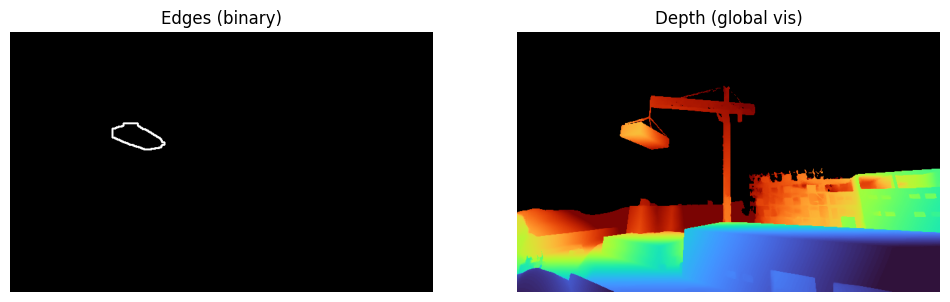

In [24]:
# Step 1: Load raw depth and edges, inspect
depth, edges_bin = load_raw(raw_dir)
print('Depth shape:', depth.shape, 'dtype:', depth.dtype, 'min:', np.nanmin(depth), 'max:', np.nanmax(depth))
print('Edges shape:', edges_bin.shape, 'dtype:', edges_bin.dtype, 'nonzero:', int((edges_bin>0).sum()))

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].imshow(edges_bin, cmap='gray'); axs[0].set_title('Edges (binary)'); axs[0].axis('off')
# Quick depth visualization (global)
valid = np.isfinite(depth) & (depth > 0)
if valid.any():
    dmin = float(np.percentile(depth[valid], 5)); dmax = float(np.percentile(depth[valid], 95))
    d_vis = visualize_depth(depth)
    axs[1].imshow(d_vis[..., ::-1]); axs[1].set_title('Depth (global vis)'); axs[1].axis('off')
else:
    axs[1].imshow(np.zeros((*depth.shape,3), dtype=np.uint8)); axs[1].set_title('Depth (no valid)'); axs[1].axis('off')
plt.show()

In [25]:
# Step 2: Optionally flatten far depths (depth > T := flatten_far_m)
#if flatten_far_m is not None:
#    T = float(flatten_far_m)
#    far_mask = np.isfinite(depth) & (depth > T)
#    changed = int(far_mask.sum())
#    if changed > 0:
#        depth = depth.copy(); depth[far_mask] = T
#    print(f'Flattened far depths above {T} m. Pixels changed:', changed)
#else:
#    print('No flattening applied.')

Buffered edges nonzero: 2553


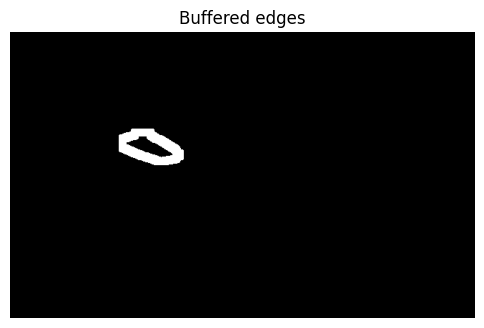

In [26]:
# Step 3: Buffer edges and visualize
buf = buffer_edges(edges_bin, buffer_px)
print('Buffered edges nonzero:', int((buf>0).sum()))

fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.imshow(buf, cmap='gray'); ax.set_title('Buffered edges'); ax.axis('off')
plt.show()

ROI: (144, 128, 250, 194)


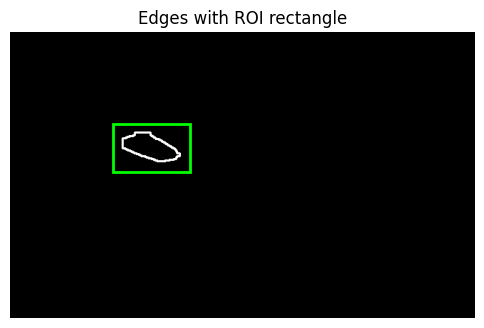

In [27]:
# Step 4: ROI from buffered mask
roi = compute_roi_from_mask(buf, roi_margin_px)
print('ROI:', roi)

# Visualize ROI rectangle on edges for context
fig, ax = plt.subplots(1, 1, figsize=(6,5))
ax.imshow(edges_bin, cmap='gray')
if roi is not None:
    x1, y1, x2, y2 = roi
    import matplotlib.patches as patches
    rect = patches.Rectangle((x1, y1), (x2-x1+1), (y2-y1+1), linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    ax.set_title('Edges with ROI rectangle')
else:
    ax.set_title('Edges (no ROI found)')
ax.axis('off')
plt.show()

depth_roi shape: (67, 107) min: 0.0 max: 98.216255


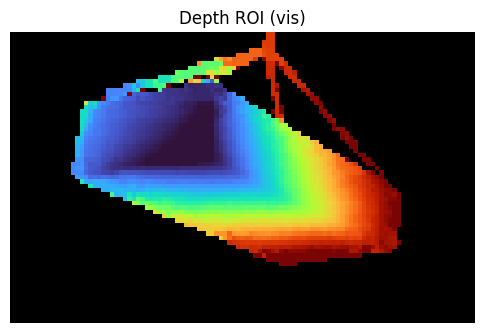

In [28]:
# Step 5: Clip depth to ROI and visualize
if roi is not None:
    x1, y1, x2, y2 = roi
    depth_roi = depth[y1:y2+1, x1:x2+1]
    print('depth_roi shape:', depth_roi.shape, 'min:', np.nanmin(depth_roi), 'max:', np.nanmax(depth_roi))
    depth_roi_vis = visualize_depth(depth_roi)
    plt.figure(figsize=(6,5))
    plt.imshow(depth_roi_vis[..., ::-1]); plt.title('Depth ROI (vis)'); plt.axis('off')
    plt.show()
else:
    print('No ROI – skipping depth ROI step.')

Gradient shape: (67, 107) min: 0.0 max: 255.0
Depth-edges nonzero: 316


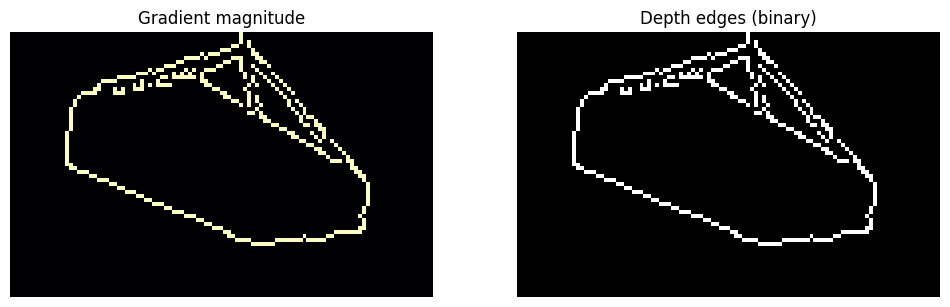

In [29]:
# Step 6: Detect depth edges inside ROI and visualize
if roi is not None:
    grad, depth_edges = detect_depth_edges(depth_roi, method, edge_thresh, edge_sigma)
    print('Gradient shape:', grad.shape, 'min:', float(np.min(grad)), 'max:', float(np.max(grad)))
    print('Depth-edges nonzero:', int((depth_edges>0).sum()))

    fig, axs = plt.subplots(1, 2, figsize=(12,5))
    axs[0].imshow(grad, cmap='magma'); axs[0].set_title('Gradient magnitude'); axs[0].axis('off')
    axs[1].imshow(depth_edges, cmap='gray'); axs[1].set_title('Depth edges (binary)'); axs[1].axis('off')
    plt.show()
else:
    print('No ROI – skipping edge detection step.')

Filtered depth edges with max distance 2.5px: kept 201 / 316


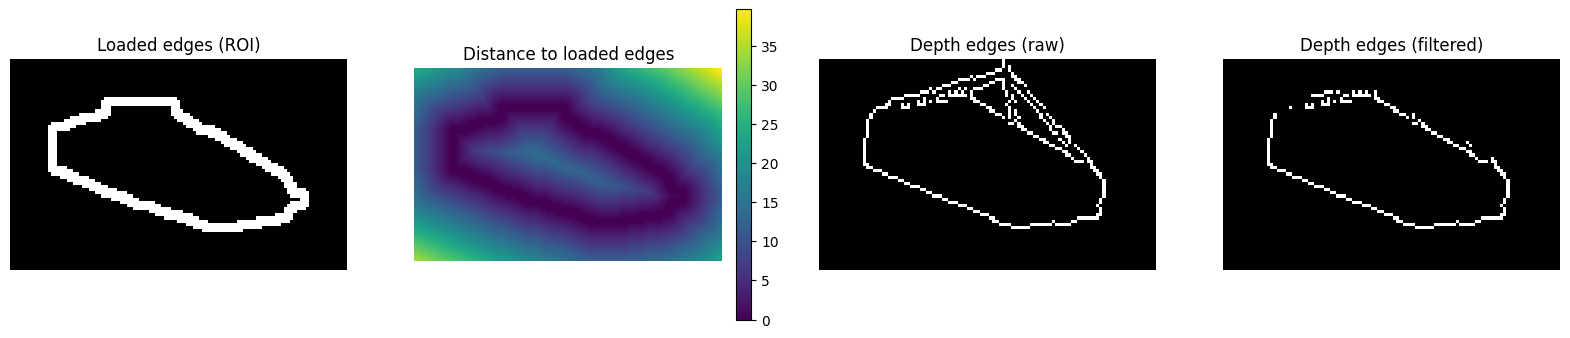

In [30]:
# Step 6.5: Filter depth edges by proximity to loaded edges (within ROI)
if roi is not None:
    # Extract loaded edges within ROI
    loaded_edges_roi = (edges_bin[y1:y2+1, x1:x2+1] > 0).astype(np.uint8)
    # Distance to nearest loaded edge (in pixels)
    # For distanceTransform, non-zero is foreground; distance is computed to nearest zero.
    # We want distance to the loaded edges => compute DT on the inverse mask (non-edge=1, edge=0)
    inv = (1 - loaded_edges_roi).astype(np.uint8) * 255
    dt = cv2.distanceTransform(inv, cv2.DIST_L2, 3)
    # Keep only depth-edge pixels that are close enough to any loaded edge
    max_d = float(max_edge_dist_px)
    valid = dt <= max_d
    depth_edges_filtered = ((depth_edges > 0) & valid).astype(np.uint8) * 255
    kept = int((depth_edges_filtered > 0).sum())
    total = int((depth_edges > 0).sum())
    print(f'Filtered depth edges with max distance {max_d}px: kept {kept} / {total}')

    # Visualize comparison
    fig, axs = plt.subplots(1, 4, figsize=(20,5))
    axs[0].imshow(loaded_edges_roi, cmap='gray'); axs[0].set_title('Loaded edges (ROI)'); axs[0].axis('off')
    im1 = axs[1].imshow(dt, cmap='viridis'); axs[1].set_title('Distance to loaded edges'); axs[1].axis('off')
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    axs[2].imshow(depth_edges, cmap='gray'); axs[2].set_title('Depth edges (raw)'); axs[2].axis('off')
    axs[3].imshow(depth_edges_filtered, cmap='gray'); axs[3].set_title('Depth edges (filtered)'); axs[3].axis('off')
    plt.show()
else:
    print('No ROI – skipping proximity filtering step.')

Closed loops (dilate + approxPolyDP): 1 (area >= 10 px, epsilon_frac=0.001)
Shrunk loops (after erode): 1
Best loop (shrunk approx): area = 2067.5 perimeter = 216.06601512432098


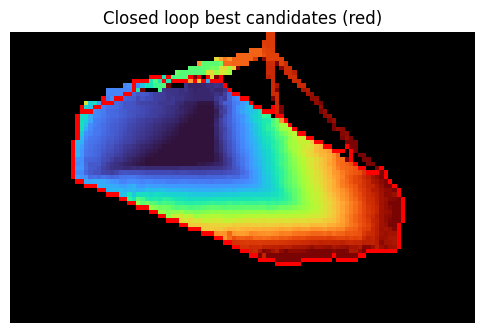

In [31]:
# Step 7: Find closed loops with dilation + polygon approximation (approxPolyDP)
if roi is not None:
    # Build a binary mask directly from filtered depth edges within ROI
    mask = (depth_edges_filtered > 0).astype(np.uint8) * 255

    # Dilate to thicken edges and bridge tiny gaps
    k = max(1, int(round(buffer_px / 2)))
    ks =  2*k + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ks, ks))
    dilated = cv2.dilate(mask, kernel, iterations=1)

    # Find contours on the dilated mask
    cnts, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Approximate each contour with a polygon and keep only meaningful closed loops
    epsilon_frac = 0.001  # fraction of perimeter for approxPolyDP; tweak if oversimplified/over-detailed
    min_area = 10         # minimum enclosed area to keep a loop (px)

    approx_loops = []
    for c in cnts:
        peri = float(cv2.arcLength(c, True))
        if peri <= 0:
            continue
        eps = float(epsilon_frac * peri)
        approx = cv2.approxPolyDP(c, eps, True)
        if approx is None or len(approx) < 4:
            continue
        area = float(cv2.contourArea(approx))
        if area < min_area:
            continue
        approx_loops.append(approx)

    print(f'Closed loops (dilate + approxPolyDP): {len(approx_loops)} (area >= {min_area} px, epsilon_frac={epsilon_frac})')

    # Shrink each approximated polygon to compensate for the dilation we applied earlier.
    # We do this by rasterizing the polygon to a mask and then eroding using the same kernel.
    shrunk_loops = []
    h, w = depth_roi.shape[:2]
    for approx in approx_loops:
        poly_mask = np.zeros((h, w), dtype=np.uint8)
        pts = approx.reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(poly_mask, [pts], 255)
        # Erode to shift boundary inward by roughly the dilation radius
        eroded = cv2.erode(poly_mask, kernel, iterations=1)
        # Extract contours from the eroded mask and re-approximate
        cnts2, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts2:
            continue
        c2 = max(cnts2, key=cv2.contourArea)
        peri2 = float(cv2.arcLength(c2, True))
        if peri2 <= 0:
            continue
        eps2 = float(epsilon_frac * peri2)
        approx2 = cv2.approxPolyDP(c2, eps2, True)
        if approx2 is None or len(approx2) < 4:
            continue
        area2 = float(cv2.contourArea(approx2))
        if area2 < min_area:
            continue
        shrunk_loops.append(approx2)

    print(f'Shrunk loops (after erode): {len(shrunk_loops)}')

    # Visualize: all approximated (shrunk) loops in yellow, best (largest area => outermost) in green with bbox
    vis = depth_roi_vis.copy()
    best_loop = None
    if shrunk_loops:
        best_loop = max(shrunk_loops, key=cv2.contourArea)
        cv2.drawContours(vis, [best_loop], -1, (0, 0, 255), 1)
        print('Best loop (shrunk approx): area =', float(cv2.contourArea(best_loop)), 'perimeter =', float(cv2.arcLength(best_loop, True)))
    else:
        print('No sufficiently large closed loops found after shrinking.')

    plt.figure(figsize=(6,5))
    plt.imshow(vis[..., ::-1])
    plt.title('Closed loop best candidates (red)')
    plt.axis('off')
    plt.show()
else:
    print('No ROI – skipping closed loop detection step.')


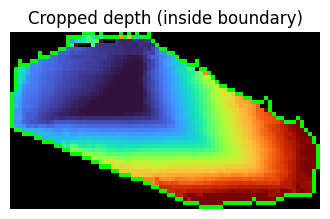

Saved depth+mask+polygon to c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files\output_3d_blocks\raw\depth_boundary.npz
Saved arrays: depth_roi (full ROI), mask (ROI-size binary mask), polygon (Nx2 int coords), bbox, cropped_depth, cropped_mask
Saved point cloud to c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files\output_3d_blocks\raw\depth_boundary.ply
Wrote shortcut c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files\output_3d_blocks\raw\last_export_pointcloud.json


In [32]:
# Step 8: Extract depth data within the selected boundary, visualize (ROI + cropped) and save for downstream use
import time

if roi is not None and 'best_loop' in globals() and best_loop is not None:
    # Determine destination directory (prefer raw_dir if available)
    dest_dir = raw_dir if (raw_dir is not None and os.path.isdir(raw_dir)) else os.getcwd()

    # best_loop is a contour in ROI coordinates
    poly = best_loop.reshape(-1, 2).astype(np.int32)

    # Build mask for the polygon (1 inside, 0 outside)
    mask = np.zeros(depth_roi.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [poly], 1)

    # Extract depth values inside polygon
    depth_inside = depth_roi.copy()
    # Option: set outside to 0 or np.nan; here we keep 0 for ease of saving/consumption
    depth_outside_zero = depth_inside.copy()
    depth_outside_zero[mask == 0] = 0

    # Compute bounding box of polygon and crop for compact storage
    bx, by, bw, bh = cv2.boundingRect(poly)
    if bw <= 0 or bh <= 0:
        print('Invalid bbox; nothing to crop')
    else:
        cropped_depth = depth_outside_zero[by:by+bh, bx:bx+bw]
        cropped_mask = mask[by:by+bh, bx:bx+bw]

        try:
            # --- Visualization: cropped depth (only bbox region) with polygon drawn in local coords
            # Prepare cropped visualization using visualize_depth (set outside to nan so it's blank)
            tmp = cropped_depth.copy().astype(np.float32)
            tmp[cropped_mask == 0] = np.nan
            cropped_vis = visualize_depth(tmp)

            # Draw polygon shifted to local (cropped) coordinates
            poly_local = (poly - np.array([bx, by])).reshape(-1, 2).astype(np.int32)
            cropped_vis_draw = cropped_vis.copy()
            # If polygon has at least 2 points draw polylines, else draw contour
            if poly_local.shape[0] >= 2:
                cv2.polylines(cropped_vis_draw, [poly_local], True, (0, 255, 0), thickness=1)

            plt.figure(figsize=(4,4))
            plt.imshow(cropped_vis_draw[..., ::-1])
            plt.title('Cropped depth (inside boundary)')
            plt.axis('off')
            plt.show()
        except Exception as e:
            print('Visualization failed:', e)

        # Compose export filename
        ts = time.strftime('%Y%m%d_%H%M%S', time.localtime())
        fname = os.path.join(dest_dir, f'depth_boundary.npz')

        # Save compressed .npz containing full ROI depth, mask, polygon, bbox and cropped arrays
        np.savez_compressed(
            fname,
            depth_roi=depth_roi,
            mask=mask,
            polygon=poly,
            bbox=(int(bx), int(by), int(bw), int(bh)),
            cropped_depth=cropped_depth,
            cropped_mask=cropped_mask,
        )

        print('Saved depth+mask+polygon to', fname)
        print('Saved arrays: depth_roi (full ROI), mask (ROI-size binary mask), polygon (Nx2 int coords), bbox, cropped_depth, cropped_mask')

        # --- Export a point cloud (PLY) of the masked points so the 3D pipeline can consume it directly
        pts = []
        # cropped_mask and cropped_depth are local (bbox-local). We'll compute global image coords for X,Y so the cloud is in image-space + depth as Z.
        rows, cols = np.where(cropped_mask > 0)
        for r, c in zip(rows, cols):
            z = float(cropped_depth[r, c])
            # ignore invalid depth
            if not np.isfinite(z) or z <= 0:
                continue
            # global image coordinates (x = column, y = row) relative to the full image
            gx = float(x1 + bx + c)
            gy = float(y1 + by + r)
            pts.append((gx, gy, z))

        if pts:
            ply_fname = os.path.join(dest_dir, f'depth_boundary.ply')
            try:
                # Prefer Open3D if available for robust writing
                import open3d as o3d
                pcd_o3d = o3d.geometry.PointCloud()
                pcd_o3d.points = o3d.utility.Vector3dVector(np.array(pts))
                o3d.io.write_point_cloud(ply_fname, pcd_o3d)
            except Exception:
                # Fallback: write a simple ASCII PLY
                try:
                    with open(ply_fname, 'w') as f:
                        f.write('ply\n')
                        f.write('format ascii 1.0\n')
                        f.write(f'element vertex {len(pts)}\n')
                        f.write('property float x\nproperty float y\nproperty float z\n')
                        f.write('end_header\n')
                        for x, y, z in pts:
                            f.write(f'{x} {y} {z}\n')
                except Exception as e:
                    print('Failed to write PLY fallback:', e)

            # Also write a small JSON shortcut file (timestamped) so other notebooks can auto-discover the exported ply
            json_path = os.path.join(dest_dir, f'last_export_pointcloud.json')
            try:
                with open(json_path, 'w') as j:
                    json.dump({'point_cloud': ply_fname}, j)
            except Exception as e:
                print('Failed to write JSON shortcut:', e)

            print('Saved point cloud to', ply_fname)
            print('Wrote shortcut', json_path)
        else:
            print('No valid 3D points found in cropped mask - no point cloud saved.')
else:
    print('No ROI or no best_loop found — nothing to save or visualize.')
